# Analyse de la relation entre le niveau d'étude attendu et la difficulté à recruter dans les emplois de la transition écologique 


Ce Notebook analyse la relation entre le niveau d'étude attendu et la difficulté à recruter par type d'emploi.
Trois hypothèses sont concurrentes :

**- H1 => Les emplois les plus qualifiés sont les plus difficiles à pourvoir.** Cela pourrait s'expliquer par un deficit d'offre de formations supérieures dans les spécialités liées à la transition écologique en comparaison à la demande émanant du marché du travail

**- H2 => Les emplois les moins qualifiés sont les plus difficiles à pourvoir.** Cela pourrait s'expliquer par l'attrait des emplois de la transition écologique auprès de la main d'oeuvre qualifiée, ou à l'inverse par le deficit d'offre de formation professionnelle menant aux emplois les moins qualifiés

**- H3 => Pas de d'impact du niveau de diplôme attendu sur la difficulté à recruter.**

## Données utilisées

- Les données concernant de l'enquête BMO 2025 sont utilisées pour calculer l'indicateur *difficulté à recruter* pour chaque famille professionnelle. Elles sont accessibles via ce lien : https://www.data.gouv.fr/datasets/enquete-besoins-en-main-doeuvre-bmo
- L'API *Offres d'emplois v2* de France Travail a été utilisé pour recenser les offres d'emploi en 2025, et identifier le niveau d'étude attendu pour chacunes d'entre elles.
- La classification des métiers verts et verdissants provient du Ministère de l'Écologie (ONEMEV) - https://www.ecologie.gouv.fr/sites/default/files/documents/Onemev_emploi_metiers.pdf


## Définitions

**- Métiers verts** - métier dont la finalité et/ou les compétences mises en œuvre contribuent à mesurer, prévenir, maîtriser, corriger les impacts négatifs et les dommages sur l’environnement

**- Métiers verdissants** - métier dont la finalité n’est pas environnementale, mais qui intègre de nouvelles « briques de compétence » pour prendre en compte de façon significative et quantifiable la dimension environnementale dans le geste métier


## Difficultés notables et limites des données employées

- La nomenclature d'emplois des deux jeux de données est différente. Les offres d'emploi recensées par France Travail sont rattachées à des codes ROME (Répertoire opérationnel des métiers et des emplois), alors que l'enquête BMO 2025 utilise les familles professionnelles (FAP 2021). Ces nomenclatures ne correspondant pas directement, le travail de matching a nécessité de faire des choix limitant la précision du travail d'analyse.
- Seulement un quart environ des offres d'emploi recensées sur France Travail avaient renseigné le champ formation, ce qui indique un potentiel risque de biais
- L'indicateur  *difficulté à recruter* est basé sur du déclaratif de la part des entreprises — il reflète la perception des employeurs, pas une mesure objective de la tension

  
## Structure de l'analyse


- Accès à l'API de France travail et exploration des offres
- Calcul de niveau d'étude attendu moyen par code ROME
- Import de la liste des codes ROME *verts* et *verdissants* (générée par ailleurs)
- Correspondance des ROME avec la nomenclature FAP 2021
- Calcul du niveau d'étude moyen attendu par FAP 2021 (moyenne pondérée des ROME par FAP)
- Chargement du BMO 2025 et calcul du taux de difficulté par FAP
- Création d'un dataframe unique incluant les niveaux d'études attendus et les taux de difficulté par FAP
- Analyse de la corrélation entre le niveau d'étude sur le taux de difficulté par FAP en 2025, sur les métiers verts et verdissants
- Reproduction des étapes précédentes  sur les métiers non verts/verdissants (grand échantillon), dans un but de comparaison


In [1]:
import pandas as pd
import numpy as np
import requests
import time
import random
import matplotlib.pyplot as plt
from scipy import stats
from adjustText import adjust_text

# ── Identifiants API France Travail ──
CLIENT_ID = "PAR_identificationdesempl_c1a30f468bbd18e5fee4fd29ab1a9ea7b19f724ec6bd816ee30f04c5fb3822ff"
CLIENT_SECRET = "14c16c813e0bdc9df30b6ca4a19820adb8c07a52d445a0913dfbaa29696e6bed"

def get_token():
    """Obtenir un token d'accès à l'API France Travail."""
    response = requests.post(
        "https://entreprise.francetravail.fr/connexion/oauth2/access_token",
        params={"realm": "/partenaire"},
        data={
            "grant_type": "client_credentials",
            "client_id": CLIENT_ID,
            "client_secret": CLIENT_SECRET,
            "scope": "api_offresdemploiv2 o2dsoffre"
        }
    )
    return response.json()["access_token"]

token = get_token()
token_time = time.time()
print("Authentification réussie ✓")

Authentification réussie ✓


# Collecte des offres


In [3]:
def collecter_offres(codes_rome, label=""):
    """
    Collecter les données de formation depuis l'API France Travail
    pour une liste de codes ROME.
    Retourne un DataFrame avec une ligne par formation par offre.
    """
    global token, token_time
    
    niveaux_map = {
        "Aucune formation scolaire": 0,
        "Primaire à 4ème": 0,
        "3ème achevée ou Brevet": 1,
        "4ème achevée": 1,
        "2nd ou 1ère achevée": 2,
        "CAP, BEP et équivalents": 3,
        "Bac ou équivalent": 4,
        "Bac+2 ou équivalents": 5,
        "Bac+3, Bac+4 ou équivalents": 6,
        "Bac+5 et plus ou équivalents": 7
    }
    
    resultats = []
    
    for i, code_rome in enumerate(codes_rome):
        # Renouveler le token si nécessaire
        if time.time() - token_time > 1200:
            token = get_token()
            token_time = time.time()
            print("Token renouvelé ✓")
        
        response = requests.get(
            "https://api.francetravail.io/partenaire/offresdemploi/v2/offres/search",
            headers={"Authorization": f"Bearer {token}"},
            params={"codeROME": code_rome, "range": "0-149"}
        )
        
        if response.status_code in [200, 206]:
            offres = response.json().get("resultats", [])
            for offre in offres:
                for formation in offre.get("formations", []):
                    niveau_libelle = formation.get("niveauLibelle", "")
                    niveau_num = niveaux_map.get(niveau_libelle, None)
                    if niveau_num is not None:
                        resultats.append({
                            "code_rome": code_rome,
                            "intitule_offre": offre.get("intitule", ""),
                            "niveau_formation": niveau_libelle,
                            "niveau_num": niveau_num
                        })
        
        time.sleep(0.3)
    
    df = pd.DataFrame(resultats)
    print(f"{label} — {len(df)} formations collectées sur {df['code_rome'].nunique()} codes ROME")
    return df

## Charger la liste des ROME verts/verdissants

In [4]:
# Charger la liste des ROME verts et verdissants
df_rome_verts = pd.read_excel(
    r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\Rome_verts.xlsx"
)
df_rome_verts.columns = ["code_rome", "categorie_vert"]
df_rome_verts["code_rome"] = df_rome_verts["code_rome"].str.strip()
df_rome_verts["categorie_vert"] = df_rome_verts["categorie_vert"].str.strip()
df_rome_verts = df_rome_verts.drop_duplicates(subset="code_rome")

print(f"Codes ROME verts/verdissants : {len(df_rome_verts)}")
print(df_rome_verts["categorie_vert"].value_counts())

Codes ROME verts/verdissants : 62
categorie_vert
VERDISSANT    52
VERT          10
Name: count, dtype: int64


## Collecter les offres pour les ROME verts/verdissants

In [5]:
# Collecter les formations pour les ROME verts/verdissants
codes_verts = df_rome_verts["code_rome"].tolist()
df_formations_verts = collecter_offres(codes_verts, label="ROME verts/verdissants")

print(f"\nNiveaux de formation :")
print(df_formations_verts["niveau_formation"].value_counts())

ROME verts/verdissants — 1832 formations collectées sur 60 codes ROME

Niveaux de formation :
niveau_formation
CAP, BEP et équivalents         556
Bac+2 ou équivalents            470
Bac+5 et plus ou équivalents    245
Bac ou équivalent               222
Bac+3, Bac+4 ou équivalents     169
Aucune formation scolaire       160
3ème achevée ou Brevet            5
4ème achevée                      4
2nd ou 1ère achevée               1
Name: count, dtype: int64


## Calculer le niveau d'études minimum par offre puis moyen par ROME

Si une offre indique plusieurs niveau d'étude acceptables, nous retenons le niveau le plus bas

# Niveau minimum par offre 
df_min_verts = df_formations_verts.groupby(
    ["code_rome", "intitule_offre"]
).agg(
    niveau_num=("niveau_num", "min")
).reset_index()

# Niveau moyen par ROME (moyenne pondérée par nombre d'offres)
df_niveau_rome = df_min_verts.groupby("code_rome").agg(
    niveau_moyen=("niveau_num", "mean"),
    nb_offres=("niveau_num", "count")
).reset_index()

df_niveau_rome["niveau_moyen"] = df_niveau_rome["niveau_moyen"].round(2)

# Ajouter la catégorie vert/verdissant
df_niveau_rome = df_niveau_rome.merge(
    df_rome_verts[["code_rome", "categorie_vert"]],
    on="code_rome", how="left"
)

print(f"Codes ROME avec niveau calculé : {len(df_niveau_rome)}")
print(df_niveau_rome.sort_values("niveau_moyen", ascending=False).head(10).to_string())

## Charger la table de correspondance ROME → FAP2021

In [8]:
# Charger la table de correspondance ROME -> FAP2021
df_fap2021 = pd.read_excel(
    r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\Dares_Table_passage_ROME_Qualif_to_FAP2021_pour_visualisation.xlsx",
    sheet_name="ROME_Qualif_to_FAP341"
)
df_fap2021.columns = ["code_rome", "qualification", "libelle_rome", "code_fap2021", "libelle_fap2021"]

# Tronquer les codes FAP2021 à 5 caractères pour matcher le BMO
df_fap2021["code_fap2021_court"] = df_fap2021["code_fap2021"].str[:5]

# Table de correspondance ROME -> FAP2021 (une ligne par combinaison unique)
df_rome_fap2021 = df_fap2021[["code_rome", "code_fap2021_court", "libelle_fap2021"]]\
    .drop_duplicates(subset=["code_rome", "code_fap2021_court"])

print(f"Codes ROME dans la table FAP2021 : {df_rome_fap2021['code_rome'].nunique()}")
print(f"Codes FAP2021 distincts : {df_rome_fap2021['code_fap2021_court'].nunique()}")

Codes ROME dans la table FAP2021 : 532
Codes FAP2021 distincts : 226


## Calculer le niveau d'études moyen par FAP2021

In [10]:
# Joindre ROME -> FAP2021
df_niveau_fap = df_niveau_rome.merge(
    df_rome_fap2021[["code_rome", "code_fap2021_court", "libelle_fap2021"]],
    on="code_rome", how="left"
)

# Récupérer le libellé FAP2021 le plus fréquent par code court
df_libelles = df_fap2021.groupby("code_fap2021_court")["libelle_fap2021"]\
    .first().reset_index()\
    .rename(columns={"code_fap2021_court": "code_fap", "libelle_fap2021": "libelle_fap"})

# Moyenne pondérée du niveau d'études par FAP2021
df_niveau_fap = df_niveau_fap.groupby("code_fap2021_court").apply(
    lambda x: pd.Series({
        "niveau_moyen": (x["niveau_moyen"] * x["nb_offres"]).sum() / x["nb_offres"].sum(),
        "nb_offres_total": x["nb_offres"].sum(),
        "nb_rome": x["code_rome"].nunique()
    })
).reset_index().rename(columns={"code_fap2021_court": "code_fap"})

df_niveau_fap["niveau_moyen"] = df_niveau_fap["niveau_moyen"].round(2)

# Ajouter libellé FAP et catégorie vert/verdissant
df_niveau_fap = df_niveau_fap.merge(df_libelles, on="code_fap", how="left")

# Catégorie FAP : VERT si au moins un ROME vert
df_cat_fap = df_niveau_rome.merge(
    df_rome_fap2021[["code_rome", "code_fap2021_court"]],
    on="code_rome", how="left"
).groupby("code_fap2021_court").agg(
    categorie_vert=("categorie_vert", lambda x: "VERT" if "VERT" in x.values else "VERDISSANT")
).reset_index().rename(columns={"code_fap2021_court": "code_fap"})

df_niveau_fap = df_niveau_fap.merge(df_cat_fap, on="code_fap", how="left")

print(f"FAP avec niveau d'études calculé : {len(df_niveau_fap)}")
print(f"  dont VERT       : {(df_niveau_fap['categorie_vert']=='VERT').sum()}")
print(f"  dont VERDISSANT : {(df_niveau_fap['categorie_vert']=='VERDISSANT').sum()}")
print(df_niveau_fap.sort_values("niveau_moyen", ascending=False).head(10)\
    [["code_fap", "libelle_fap", "categorie_vert", "niveau_moyen", "nb_offres_total"]].to_string())

FAP avec niveau d'études calculé : 62
  dont VERT       : 9
  dont VERDISSANT : 53
   code_fap                                                                                                                                        libelle_fap categorie_vert  niveau_moyen  nb_offres_total
34    H1X93                                                            Ingénieurs et cadres techniques en management et ingénierie qualité industrielle et BTP     VERDISSANT          7.00              8.0
19    B7X90                                                                                                                                        Architectes     VERDISSANT          6.63             27.0
51    N1X90                                                                               Ingénieurs et cadres d'étude, recherche et développement (industrie)     VERDISSANT          6.53             32.0
50    N0X70                                                                                      

C:\Users\Clément FAYS\AppData\Local\Temp\ipykernel_13724\2779271051.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_niveau_fap = df_niveau_fap.groupby("code_fap2021_court").apply(


## Charger le BMO 2025 et calculer le taux de difficulté par FAP2021

In [11]:
# Charger le BMO 2025
df_bmo = pd.read_excel(
    r"C:\Users\Clément FAYS\OneDrive - Agence universitaire de la Francophonie\Bureau\Divers\Python\Formation\BMO\Données BMO annuelles\Base_open_data_BMO_2025.xlsx",
    sheet_name="BMO_2025_open_data" 
)

# Nettoyages
df_bmo["met"] = pd.to_numeric(df_bmo["met"], errors="coerce")
df_bmo["xmet"] = pd.to_numeric(df_bmo["xmet"], errors="coerce")
df_bmo["Code métier BMO"] = df_bmo["Code métier BMO"].str.replace("\xa0", " ").str.strip()

# Calculer le taux de difficulté par FAP2021
df_taux_fap = df_bmo.groupby("Code métier BMO").agg(
    recrutements=("met", "sum"),
    recrutements_difficiles=("xmet", "sum")
).reset_index()

df_taux_fap["taux_difficulte"] = (
    df_taux_fap["recrutements_difficiles"] / df_taux_fap["recrutements"] * 100
).round(1)

df_taux_fap = df_taux_fap.rename(columns={"Code métier BMO": "code_fap"})

print(f"FAP dans le BMO 2025 : {len(df_taux_fap)}")
print(df_taux_fap.head(5).to_string())

FAP dans le BMO 2025 : 217
  code_fap  recrutements  recrutements_difficiles  taux_difficulte
0    A0X40       92905.0                  44417.0             47.8
1    A0X41        6702.0                   3713.0             55.4
2    A0X42        3181.0                   2219.0             69.8
3    A0X43        5667.0                   3437.0             60.6
4    A1X40       21710.0                  11524.0             53.1


## Création du df final

Jointure niveau d'études / taux de difficulté

In [12]:
# Jointure finale
df_final = df_niveau_fap.merge(
    df_taux_fap[["code_fap", "taux_difficulte"]],
    on="code_fap", how="left"
).dropna(subset=["niveau_moyen", "taux_difficulte"])

print(f"FAP dans l'analyse finale : {len(df_final)}")
print(f"  dont VERT       : {(df_final['categorie_vert']=='VERT').sum()}")
print(f"  dont VERDISSANT : {(df_final['categorie_vert']=='VERDISSANT').sum()}")
print(df_final[["code_fap", "libelle_fap", "categorie_vert", "niveau_moyen", "taux_difficulte"]]\
    .sort_values("taux_difficulte", ascending=False).head(10).to_string())

FAP dans l'analyse finale : 59
  dont VERT       : 9
  dont VERDISSANT : 50
   code_fap                                                                                                             libelle_fap categorie_vert  niveau_moyen  taux_difficulte
7     B1X34                                                                                                 Couvreurs peu qualifiés     VERDISSANT          3.28             82.0
28    G1X74                      Techniciens et agents de maîtrise en installation et maintenance en froid et conditionnement d'air     VERDISSANT          2.93             79.4
6     B1X33                                                                                              Charpentiers peu qualifiés     VERDISSANT          2.89             78.1
27    G1X72                       Techniciens et agents de maîtrise en maintenance mécanique et entretien d'équipements industriels           VERT          2.00             75.0
24    G0B41                       

## Analyse de la corrélation études/difficulté à recruter
Régression linéaire sur les FAP verts/verdissants

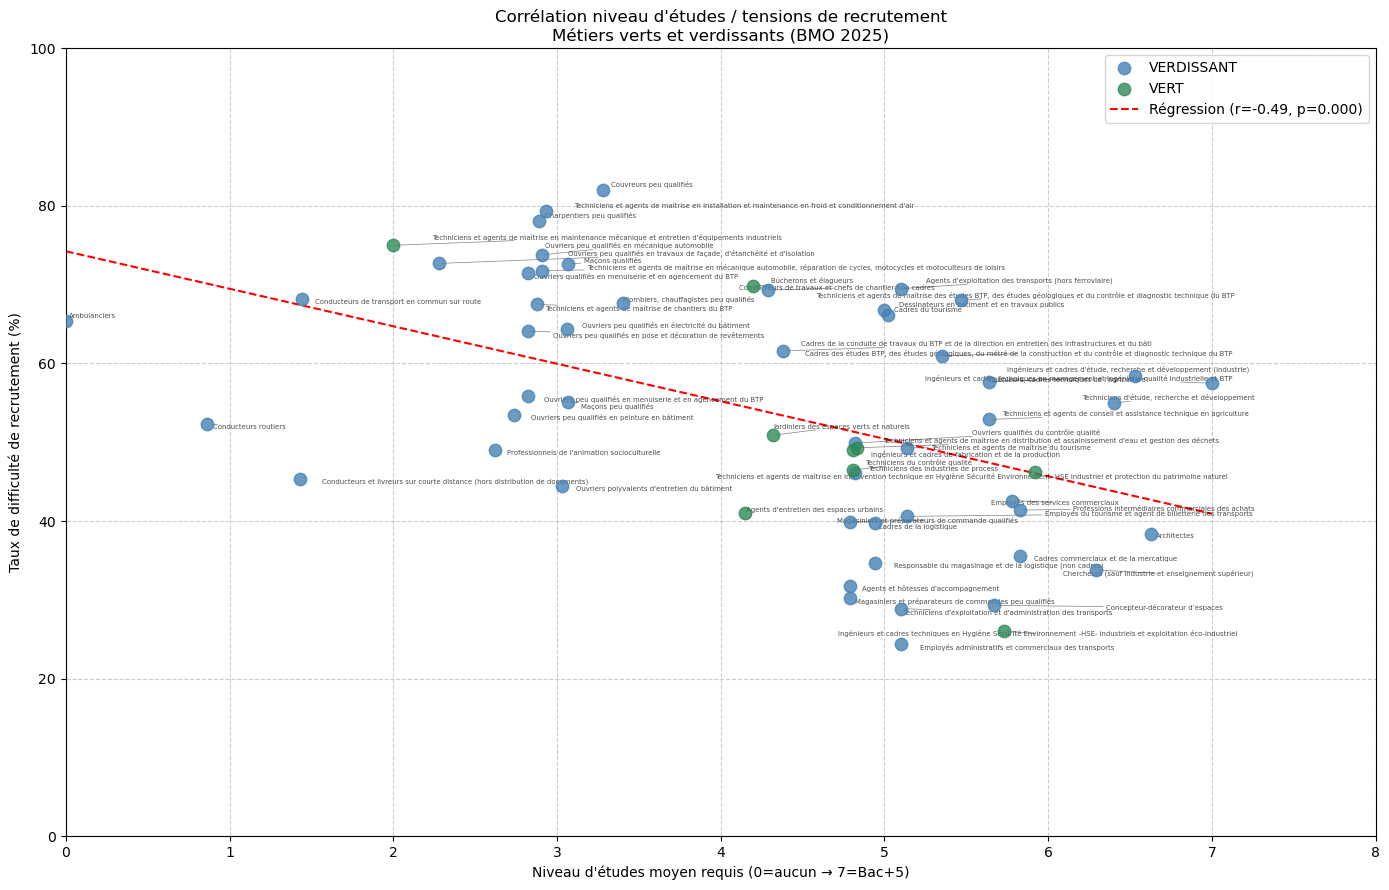

r = -0.49, p = 0.000, pente = -4.76


In [13]:
df_plot = df_final.copy()

fig, ax = plt.subplots(figsize=(14, 9))
colors = {"VERT": "seagreen", "VERDISSANT": "steelblue"}
texts = []

for categorie, groupe in df_plot.groupby("categorie_vert"):
    ax.scatter(
        groupe["niveau_moyen"], groupe["taux_difficulte"],
        color=colors[categorie], label=categorie, alpha=0.8, s=80, zorder=5
    )
    for _, row in groupe.iterrows():
        texts.append(ax.text(
            row["niveau_moyen"], row["taux_difficulte"],
            row["libelle_fap"], fontsize=5, alpha=0.7
        ))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

slope, intercept, r, p, _ = stats.linregress(
    df_plot["niveau_moyen"], df_plot["taux_difficulte"]
)
x_line = np.linspace(df_plot["niveau_moyen"].min(), df_plot["niveau_moyen"].max(), 100)
ax.plot(x_line, slope * x_line + intercept, color="red", linestyle="--",
        linewidth=1.5, label=f"Régression (r={r:.2f}, p={p:.3f})")

ax.set_xlabel("Niveau d'études moyen requis (0=aucun → 7=Bac+5)")
ax.set_ylabel("Taux de difficulté de recrutement (%)")
ax.set_xlim(0, 8)
ax.set_ylim(0, 100)
ax.grid(linestyle="--", alpha=0.4, color="gray")
ax.set_axisbelow(True)
ax.legend()

plt.title("Corrélation niveau d'études / tensions de recrutement\nMétiers verts et verdissants (BMO 2025)",
          fontsize=12)
plt.tight_layout()
plt.show()

print(f"r = {r:.2f}, p = {p:.3f}, pente = {slope:.2f}")

**Interprétation**

On observe une relation négative statistiquement significative entre le niveau d'étude attendu et le taux perçu de difficulté à recruter. Toutes choses égales par ailleurs, l'augmentation de 1 niveau d'étude attendu (dans l'échelle établie plus haut) résulte en une difficulté à recruter réduite de 4,76 points de pourcentage.
**Ces résultats vont dans le sens de l'hypothèse 2  énoncée en introduction.**

Il s'agit ici d'une analyse de corrélation qui peut difficilement être extrapolé en causalité. En effet de nombreux autres facteurs entrent sans doute en compte pour expliquer les difficultés à recruter (le niveau de salaire, la localisation géographique du poste, la pénibilité, etc.).

Nous pouvons toutefois facilement observer si cette corrélation est propres aux familles professionnelles de la transition écologique ou si elle s'applique aussi aux autres métiers. C'est ce que nous allons vérifier ci-dessous.

## Collecter les offres pour un échantillon de ROME non verts

In [14]:
# Charger tous les codes ROME disponibles
df_tous_rome = df_fap2021[["code_rome"]].drop_duplicates()

# Exclure les ROME verts/verdissants
codes_verts_set = set(df_rome_verts["code_rome"].tolist())
df_autres_rome = df_tous_rome[~df_tous_rome["code_rome"].isin(codes_verts_set)]

# Tirer 150 codes ROME aléatoires
random.seed(42)
sample_autres = df_autres_rome.sample(n=150, random_state=42)
print(f"Codes ROME non verts disponibles : {len(df_autres_rome)}")
print(f"Échantillon tiré : {len(sample_autres)}")

# Collecter les formations
df_formations_autres = collecter_offres(
    sample_autres["code_rome"].tolist(),
    label="ROME autres"
)

Codes ROME non verts disponibles : 470
Échantillon tiré : 150
ROME autres — 4004 formations collectées sur 135 codes ROME


 ## Calculer le niveau d'études par FAP2021 pour les autres métiers

In [15]:
# Niveau minimum par offre
df_min_autres = df_formations_autres.groupby(
    ["code_rome", "intitule_offre"]
).agg(niveau_num=("niveau_num", "min")).reset_index()

# Niveau moyen par ROME
df_niveau_rome_autres = df_min_autres.groupby("code_rome").agg(
    niveau_moyen=("niveau_num", "mean"),
    nb_offres=("niveau_num", "count")
).reset_index()
df_niveau_rome_autres["niveau_moyen"] = df_niveau_rome_autres["niveau_moyen"].round(2)

# Joindre avec FAP2021
df_niveau_fap_autres = df_niveau_rome_autres.merge(
    df_rome_fap2021[["code_rome", "code_fap2021_court", "libelle_fap2021"]],
    on="code_rome", how="left"
)

# Moyenne pondérée par FAP2021
df_niveau_fap_autres = df_niveau_fap_autres.groupby("code_fap2021_court").apply(
    lambda x: pd.Series({
        "niveau_moyen": (x["niveau_moyen"] * x["nb_offres"]).sum() / x["nb_offres"].sum(),
        "nb_offres_total": x["nb_offres"].sum(),
        "nb_rome": x["code_rome"].nunique()
    })
).reset_index().rename(columns={"code_fap2021_court": "code_fap"})

df_niveau_fap_autres["niveau_moyen"] = df_niveau_fap_autres["niveau_moyen"].round(2)
df_niveau_fap_autres["categorie_vert"] = "Autres"

# Ajouter libellé FAP
df_niveau_fap_autres = df_niveau_fap_autres.merge(df_libelles, on="code_fap", how="left")

print(f"FAP autres avec niveau calculé : {len(df_niveau_fap_autres)}")

FAP autres avec niveau calculé : 128


C:\Users\Clément FAYS\AppData\Local\Temp\ipykernel_13724\567136518.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_niveau_fap_autres = df_niveau_fap_autres.groupby("code_fap2021_court").apply(


## Jointure taux de difficulté pour les autres métiers

In [16]:
# Taux de difficulté pour les FAP non verts/verdissants
fap_verts_set = set(df_niveau_fap["code_fap"].tolist())

df_taux_fap_autres = df_taux_fap[
    ~df_taux_fap["code_fap"].isin(fap_verts_set)
]

# Jointure
df_final_autres = df_niveau_fap_autres.merge(
    df_taux_fap_autres[["code_fap", "taux_difficulte"]],
    on="code_fap", how="left"
).dropna(subset=["niveau_moyen", "taux_difficulte"])

print(f"FAP autres dans l'analyse finale : {len(df_final_autres)}")

FAP autres dans l'analyse finale : 100


## Graphique comparatif et test de Fisher

Métiers verts (n=9) — r=-0.77, p=0.015, pente=-9.88
Métiers verdissants (n=50) — r=-0.45, p=0.001, pente=-4.29
Autres métiers (n=100) — r=-0.07, p=0.467, pente=-0.86


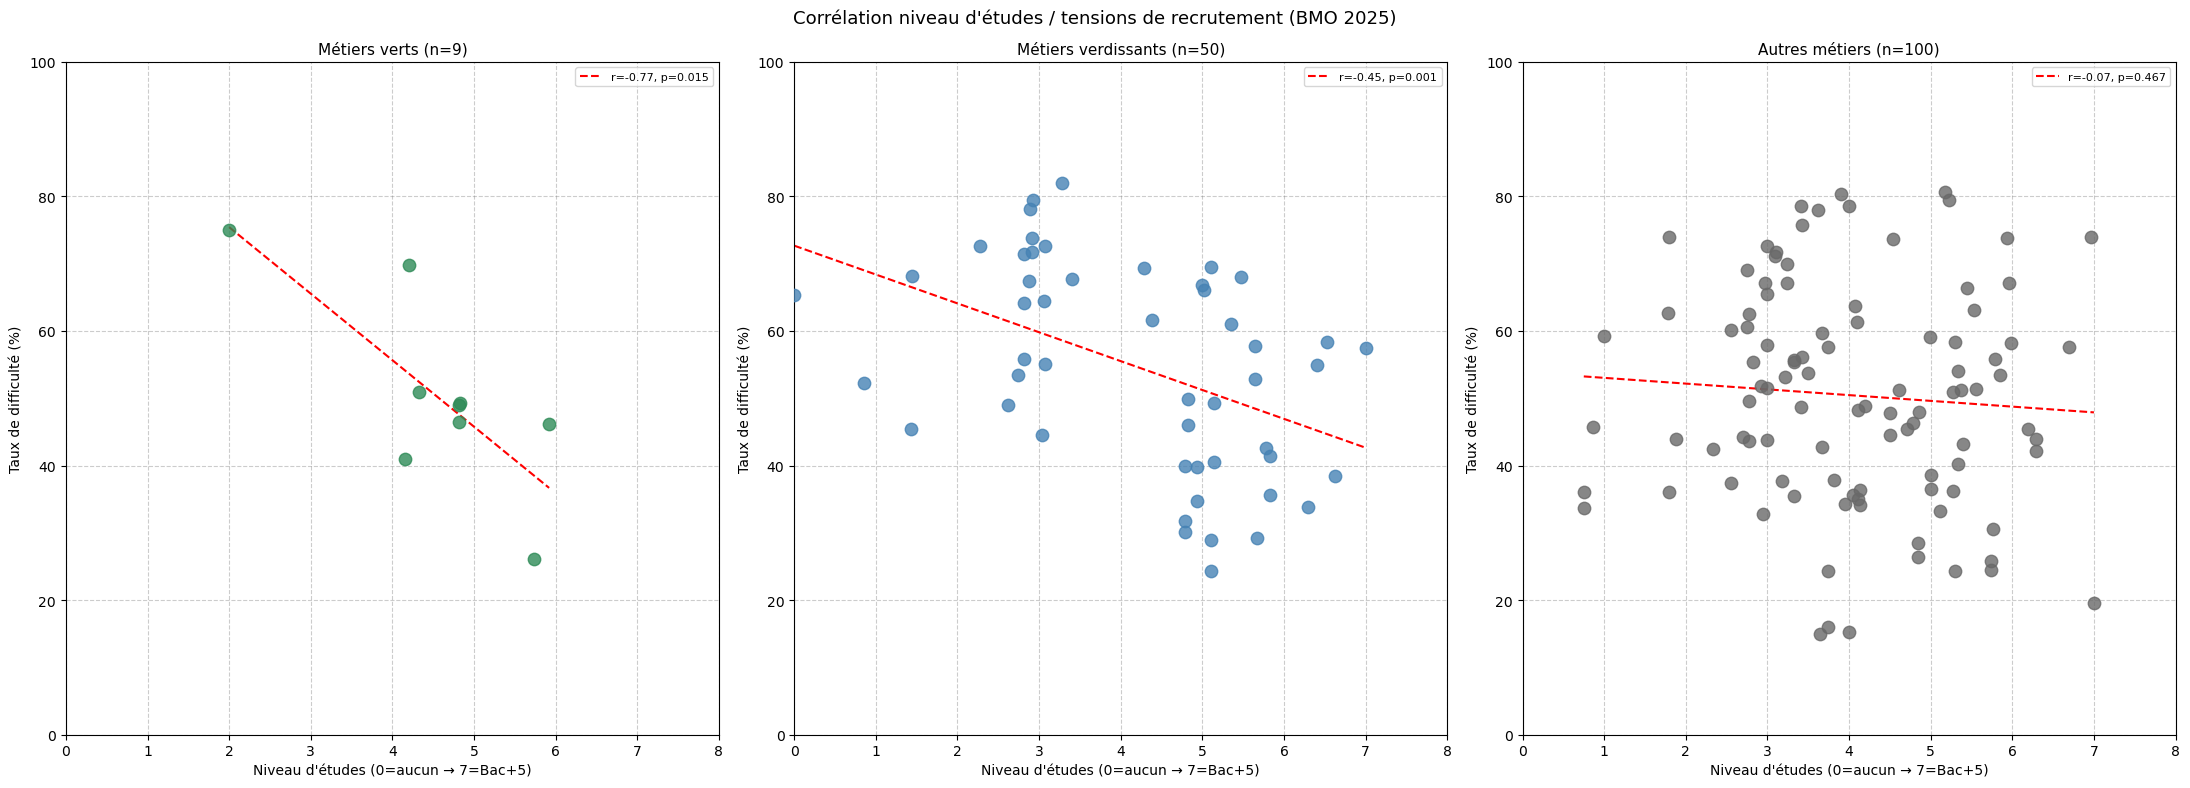


── Test de Fisher : verdissants vs autres ──
r verdissants : -0.45 (n=50)
r autres      : -0.07 (n=100)
z = -2.327, p = 0.020
→ Différence statistiquement significative (p < 0.05)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

df_verts_only = df_final[df_final["categorie_vert"] == "VERT"]
df_verdissants_only = df_final[df_final["categorie_vert"] == "VERDISSANT"]

datasets = [
    (df_verts_only, "Métiers verts", "seagreen"),
    (df_verdissants_only, "Métiers verdissants", "steelblue"),
    (df_final_autres, "Autres métiers", "dimgray")
]

resultats_regression = {}

for ax, (data, titre, color) in zip(axes, datasets):
    ax.scatter(data["niveau_moyen"], data["taux_difficulte"],
               color=color, alpha=0.8, s=80, zorder=5)

    if len(data) > 2:
        slope, intercept, r, p, _ = stats.linregress(
            data["niveau_moyen"], data["taux_difficulte"]
        )
        x_line = np.linspace(data["niveau_moyen"].min(), data["niveau_moyen"].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color="red", linestyle="--",
                linewidth=1.5, label=f"r={r:.2f}, p={p:.3f}")
        resultats_regression[titre] = {"r": r, "p": p, "n": len(data), "pente": slope}
        print(f"{titre} (n={len(data)}) — r={r:.2f}, p={p:.3f}, pente={slope:.2f}")

    ax.set_xlabel("Niveau d'études (0=aucun → 7=Bac+5)")
    ax.set_ylabel("Taux de difficulté (%)")
    ax.set_xlim(0, 8)
    ax.set_ylim(0, 100)
    ax.grid(linestyle="--", alpha=0.4, color="gray")
    ax.set_axisbelow(True)
    ax.legend(fontsize=8)
    ax.set_title(f"{titre} (n={len(data)})", fontsize=11)

plt.suptitle("Corrélation niveau d'études / tensions de recrutement (BMO 2025)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Test de Fisher : verdissants vs autres ──
print("\n── Test de Fisher : verdissants vs autres ──")
r1 = resultats_regression["Métiers verdissants"]["r"]
n1 = resultats_regression["Métiers verdissants"]["n"]
r2 = resultats_regression["Autres métiers"]["r"]
n2 = resultats_regression["Autres métiers"]["n"]

z1, z2 = np.arctanh(r1), np.arctanh(r2)
se = np.sqrt(1/(n1-3) + 1/(n2-3))
z_diff = (z1 - z2) / se
p_fisher = 2 * (1 - stats.norm.cdf(abs(z_diff)))

print(f"r verdissants : {r1:.2f} (n={n1})")
print(f"r autres      : {r2:.2f} (n={n2})")
print(f"z = {z_diff:.3f}, p = {p_fisher:.3f}")
if p_fisher < 0.05:
    print("→ Différence statistiquement significative (p < 0.05)")
else:
    print("→ Différence non statistiquement significative (p >= 0.05)")

**Interprétation**

Sur la base de l'échatillon de 150 codes ROME tirés (équivalents à 100 FAP), nous n'observons pas de relation significative entre le niveau d'étude et la difficulté à recruter dans les emplois hors transition écologique. La différence entre les coefficients est statistiquement significative, ce qui va dans le sens de l'hypothèse selon laquelle *le niveau d'étude attendu représente un facteur explicatif de la difficulté à recruter particulièrement dans les métiers de la transition écologique.*

# Conclusion

Grâce à l'exploitation et la mise en concordance de plusieurs sources de données, nous avons ici pu réaliser une rapide analyse de la relation entre niveau d'étude attendu et difficulté à recruter sur les métiers de la transition écologiques.
**Les résultats obtenus ici permettent d'observer que les emplois *verts* semblent plus difficiles à pourvoir lorsqu'ils recquièrent un niveau d'étude faible. Ce constat ne s'applique pas aux autres emplois, ce qui suggère que des mécanismes propres aux métiers de la transition sont à l'oeuvre.**

**Deux hypothèses de travail sont à explorer :**

*- Les métiers hautements qualifiés dans le domaine de la transition sont particulièrement attractifs.* Cela s'expliquerait notamment par la "quête de sens" parmi les jeunes diplomés, qui valorisent relativement plus les métiers à fort impact social - définition incluant souvent les métiers à caractère écologique.

*- Les métiers faiblement qualifiés dans le domaine de la transition sont particulièrement inattractifs.* Cela pourrait s'expliquer par la pénibilité et le manque de reconnaissance économique et social associé à ces emplois (beaucoup d'emplois dans les secteurs de la construction, de l'entretion/rénovation, du transport routier de passagers).

**Des analyses complémentaires seraient nécessaires. Des exmples de perspectives sont :**

- Introduction de nouvelles variables de contrôle dans le modèle régression pour valider la causation entre niveau de diplôme et difficulté de recrutement

- Analyse temporelle pour valider la tendance observée sur un temps plus long

- L'analyse gagnerait également en précision si l'enquête BMO utilisait la nomenclature ROME, plus granulaire que les FAP et évitant ainsi d'avoir à matcher certaines catégories de manière semi-arbitraire.

**Recommandations**

Du fait des limitations de l'analyse, il est difficile de fournir des recommandations à ce stade. Toutefois, si le phénomène observé venait à être validé par des analyses approfondies, les recommandations suivantes pourraient être émises :

- Besoin de renforcer l'attractivité des métiers les moins qualifiés qui contribuent de manière significative à la transition écologiques du pays (secteurs de la construction, de la rénovation énergétique, des transports en commun). Par exemple grâce à un système de "primes écologies", similaire au dispositif de Prime Ségur du secteur de la santé.

- Besoin de renforcer les capacités de formation professionnelles des filières de la transition écologiques, par exemple en créant de nouveaux établissements de foramtion initiale ou en renforcant les dispositifs actuels de formation continue.